In [62]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# MSTuring-100M-Clustered

In [205]:
surge_no_rebuilds_path = "/users/dkhimey/surge/shared_batch_experiment_results/msturing-100M-clustered_eco_threshold10K_sweep.csv"
surge_no_rebuilds = pd.read_csv(surge_no_rebuilds_path)

surge_t80_path = "/users/dkhimey/surge/shared_batch_experiment_results/msturing-100M-clustered_eco_threshold8K_full_sweep.csv"
surge_t80 = pd.read_csv(surge_t80_path)

surge_t60_path = "/users/dkhimey/surge/shared_batch_experiment_results/msturing-100M-clustered_eco_threshold6K_full_sweep.csv"
surge_t60 = pd.read_csv(surge_t60_path)

surge_t60_strong_path = "/users/dkhimey/surge/shared_batch_experiment_results/msturing-100M-clustered_strong_threshold6K_full_sweep.csv"
surge_t60_strong = pd.read_csv(surge_t60_strong_path)

surge_t60_strong_delta_path = "/users/dkhimey/surge/shared_batch_experiment_results/msturing-100M-clustered_strong_threshold6K_delta_sweep.csv"
surge_t60_strong_delta = pd.read_csv(surge_t60_strong_delta_path)

surge_t70_strong_path = "/users/dkhimey/surge/shared_batch_experiment_results/msturing-100M-clustered_strong_threshold7K_full_sweep.csv"
surge_t70_strong = pd.read_csv(surge_t70_strong_path)

gpann_results_path = "/dataset/gp-ann-inserts/results/msturing/msturing100Mclustered_runbook_results_nprobe_sweep.csv"
gpann_results = pd.read_csv(gpann_results_path)

In [206]:
shard_cols = ["shard_0_size","shard_1_size","shard_2_size","shard_3_size","shard_4_size","shard_5_size","shard_6_size","shard_7_size","shard_8_size","shard_9_size"]
def gini(counts):
    arr = np.sort(np.array(counts, dtype=float))
    n = len(arr)
    idx = np.arange(1, n + 1)
    return (2 * np.sum(idx * arr) / (n * np.sum(arr))) - (n + 1) / n

In [207]:
surge_no_rebuilds["gini"] = surge_no_rebuilds[shard_cols].apply(lambda row: gini(row.values), axis=1)
surge_t60["gini"] = surge_t60[shard_cols].apply(lambda row: gini(row.values), axis=1)
surge_t60_strong["gini"] = surge_t60_strong[shard_cols].apply(lambda row: gini(row.values), axis=1)
surge_t60_strong_delta["gini"] = surge_t60_strong_delta[shard_cols].apply(lambda row: gini(row.values), axis=1)

surge_t80["gini"] = surge_t80[shard_cols].apply(lambda row: gini(row.values), axis=1)
surge_t70_strong["gini"] = surge_t70_strong[shard_cols].apply(lambda row: gini(row.values), axis=1)
gpann_results["gini"] = gpann_results[shard_cols].apply(lambda row: gini(row.values), axis=1)

In [208]:
surge_t60_strong_delta[surge_t60_strong_delta["operation"] == "rebuild"]

,step,operation,range_start,range_end,time_s,throughput,recall@10,avg_parts_searched,centers_moved,elements_moved,...,shard_1_size,shard_2_size,shard_3_size,shard_4_size,shard_5_size,shard_6_size,shard_7_size,shard_8_size,shard_9_size,gini
13,13,rebuild,-1,-1,79.6623,-1.0,-1.0,-1.0,6826,2010116,...,100329,65082,121819,462288,47581,212784,58357,733660,581282,0.506714


In [210]:
surge_t60_strong_delta

,step,operation,range_start,range_end,time_s,throughput,recall@10,avg_parts_searched,centers_moved,elements_moved,...,shard_1_size,shard_2_size,shard_3_size,shard_4_size,shard_5_size,shard_6_size,shard_7_size,shard_8_size,shard_9_size,gini
0,1,insert,0,178387,0.000000,0.0,-1.00000,-1.0000,-1,-1,...,18572,18351,17918,13005,18006,18789,18299,18561,18557,0.033750
1,2,search,0,10000,0.097473,102592.0,0.75357,4.5935,-1,-1,...,18572,18351,17918,13005,18006,18789,18299,18561,18557,0.033750
2,3,insert,1692335,1723966,0.055386,571101.0,-1.00000,-1.0000,-1,-1,...,22364,22173,20162,14994,21330,23085,22201,21289,21607,0.046711
3,4,search,0,10000,0.070765,141314.0,0.73558,4.5935,-1,-1,...,22364,22173,20162,14994,21330,23085,22201,21289,21607,0.046711
4,5,insert,2962640,2986169,0.070541,333551.0,-1.00000,-1.0000,-1,-1,...,25098,22945,25315,16043,22506,27929,24887,22298,22788,0.063432
5,6,search,0,10000,0.075572,132325.0,0.72491,4.5935,-1,-1,...,25098,22945,25315,16043,22506,27929,24887,22298,22788,0.063432
6,7,insert,4244684,4472291,0.799534,284674.0,-1.00000,-1.0000,-1,-1,...,49874,40902,42686,36154,40842,72885,40917,45936,45329,0.094492
7,8,search,0,10000,0.167545,59685.3,0.70970,4.5935,-1,-1,...,49874,40902,42686,36154,40842,72885,40917,45936,45329,0.094492
8,9,insert,6016162,6516556,1.242260,402810.0,-1.00000,-1.0000,-1,-1,...,136173,95699,77313,62055,103411,153531,81276,75622,72346,0.156549
9,10,search,0,10000,0.278339,35927.5,0.65156,4.5935,-1,-1,...,136173,95699,77313,62055,103411,153531,81276,75622,72346,0.156549


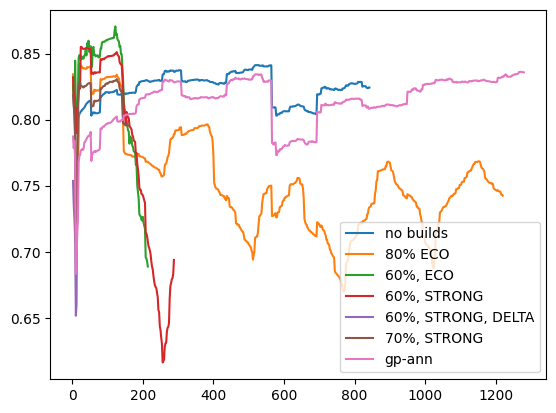

In [211]:
mode = "RecallTarget"
param = .9
gpann_param = 7

plt.plot(surge_no_rebuilds[
        (surge_no_rebuilds["operation"] == "search") &
        (surge_no_rebuilds["mode"] == mode) &
        (surge_no_rebuilds["param"] == param)
    ]["step"],
    surge_no_rebuilds[
        (surge_no_rebuilds["operation"] == "search") &
        (surge_no_rebuilds["mode"] == mode) &
        (surge_no_rebuilds["param"] == param)
    ]["recall@10"], label="no builds")

plt.plot(surge_t80[
        (surge_t80["operation"] == "search") &
        (surge_t80["mode"] == mode) &
        (surge_t80["param"] == param)
    ]["step"],
    surge_t80[
        (surge_t80["operation"] == "search") &
        (surge_t80["mode"] == mode) &
        (surge_t80["param"] == param)
    ]["recall@10"], label="80% ECO")

plt.plot(surge_t60[
        (surge_t60["operation"] == "search") &
        (surge_t60["mode"] == mode) &
        (surge_t60["param"] == param)
    ]["step"],
    surge_t60[
        (surge_t60["operation"] == "search") &
        (surge_t60["mode"] == mode) &
        (surge_t60["param"] == param)
    ]["recall@10"], label="60%, ECO")

plt.plot(surge_t60_strong[
        (surge_t60_strong["operation"] == "search") &
        (surge_t60_strong["mode"] == mode) &
        (surge_t60_strong["param"] == param)
    ]["step"],
    surge_t60_strong[
        (surge_t60_strong["operation"] == "search") &
        (surge_t60_strong["mode"] == mode) &
        (surge_t60_strong["param"] == param)
    ]["recall@10"], label="60%, STRONG")

plt.plot(surge_t60_strong_delta[
        (surge_t60_strong_delta["operation"] == "search")]["step"],
    surge_t60_strong_delta[
        (surge_t60_strong_delta["operation"] == "search")]["recall@10"], 
    label="60%, STRONG, DELTA")


plt.plot(surge_t70_strong[
        (surge_t70_strong["operation"] == "search") &
        (surge_t70_strong["mode"] == mode) &
        (surge_t70_strong["param"] == param)
    ]["step"],
    surge_t70_strong[
        (surge_t70_strong["operation"] == "search") &
        (surge_t70_strong["mode"] == mode) &
        (surge_t70_strong["param"] == param)
    ]["recall@10"], label="70%, STRONG")

plt.plot(gpann_results[
        (gpann_results["operation"] == "SEARCH") & 
        (gpann_results["nprobe"] == gpann_param)
    ]["step"],
    gpann_results[
        (gpann_results["operation"] == "SEARCH") & 
        (gpann_results["nprobe"] == gpann_param)
    ]["recall@10"], label="gp-ann")

plt.legend()

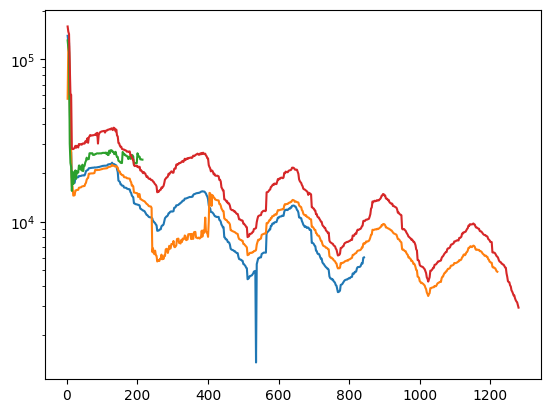

In [204]:
plt.plot(surge_no_rebuilds[
        (surge_no_rebuilds["operation"] == "search") &
        (surge_no_rebuilds["mode"] == "RecallTarget") &
        (surge_no_rebuilds["param"] == .9)
    ]["step"],
    surge_no_rebuilds[
        (surge_no_rebuilds["operation"] == "search") &
        (surge_no_rebuilds["mode"] == "RecallTarget") &
        (surge_no_rebuilds["param"] == .9)
    ]["throughput"])

plt.plot(surge_t80[
        (surge_t80["operation"] == "search") &
        (surge_t80["mode"] == "RecallTarget") &
        (surge_t80["param"] == .9)
    ]["step"],
    surge_t80[
        (surge_t80["operation"] == "search") &
        (surge_t80["mode"] == "RecallTarget") &
        (surge_t80["param"] == .9)
    ]["throughput"])

plt.plot(surge_t60[
        (surge_t60["operation"] == "search") &
        (surge_t60["mode"] == "RecallTarget") &
        (surge_t60["param"] == .9)
    ]["step"],
    surge_t60[
        (surge_t60["operation"] == "search") &
        (surge_t60["mode"] == "RecallTarget") &
        (surge_t60["param"] == .9)
    ]["throughput"])

plt.plot(gpann_results[
        (gpann_results["operation"] == "SEARCH") & 
        (gpann_results["nprobe"] == 7)
    ]["step"],
    gpann_results[
        (gpann_results["operation"] == "SEARCH") & 
        (gpann_results["nprobe"] == 7)
    ]["qps_or_throughput"])

plt.yscale("log")

In [102]:
gpann_results

,step,operation,nprobe,range_start,range_end,time_s,qps_or_throughput,recall@10,shard_0_size,shard_1_size,shard_2_size,shard_3_size,shard_4_size,shard_5_size,shard_6_size,shard_7_size,shard_8_size,shard_9_size,gini
0,1,BUILD,NaN,0,178387,0.884379,201709.00,NaN,18729,18729,18526,18729,18002,18729,18704,17246,17416,13577,0.036815
1,2,SEARCH,1.0,0,10000,0.021190,471931.00,0.27185,18729,18729,18526,18729,18002,18729,18704,17246,17416,13577,0.036815
2,2,SEARCH,2.0,0,10000,0.030186,331284.00,0.41139,18729,18729,18526,18729,18002,18729,18704,17246,17416,13577,0.036815
3,2,SEARCH,3.0,0,10000,0.043540,229672.00,0.51376,18729,18729,18526,18729,18002,18729,18704,17246,17416,13577,0.036815
4,2,SEARCH,4.0,0,10000,0.058071,172202.00,0.59791,18729,18729,18526,18729,18002,18729,18704,17246,17416,13577,0.036815
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7035,1280,SEARCH,6.0,0,10000,3.113990,3211.31,0.79104,8158460,6868317,8553524,14280247,9250921,6408222,9438955,8079307,20539533,8422343,0.189272
7036,1280,SEARCH,7.0,0,10000,3.393940,2946.43,0.83569,8158460,6868317,8553524,14280247,9250921,6408222,9438955,8079307,20539533,8422343,0.189272
7037,1280,SEARCH,8.0,0,10000,3.624060,2759.33,0.87256,8158460,6868317,8553524,14280247,9250921,6408222,9438955,8079307,20539533,8422343,0.189272
7038,1280,SEARCH,9.0,0,10000,3.827420,2612.73,0.90246,8158460,6868317,8553524,14280247,9250921,6408222,9438955,8079307,20539533,8422343,0.189272


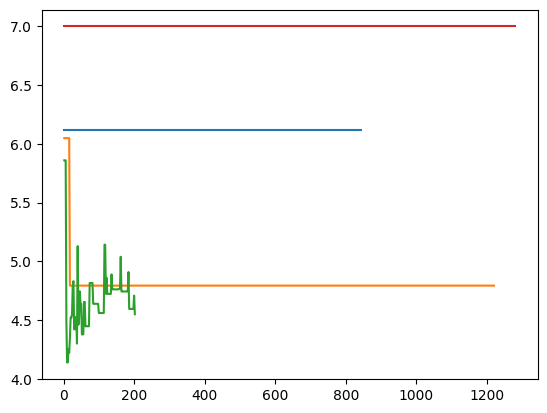

In [103]:
plt.plot(surge_no_rebuilds[
        (surge_no_rebuilds["operation"] == "search") &
        (surge_no_rebuilds["mode"] == "RecallTarget") &
        (surge_no_rebuilds["param"] == .9)
    ]["step"],
    surge_no_rebuilds[
        (surge_no_rebuilds["operation"] == "search") &
        (surge_no_rebuilds["mode"] == "RecallTarget") &
        (surge_no_rebuilds["param"] == .9)
    ]["avg_parts_searched"])

plt.plot(surge_t80[
        (surge_t80["operation"] == "search") &
        (surge_t80["mode"] == "RecallTarget") &
        (surge_t80["param"] == .9)
    ]["step"],
    surge_t80[
        (surge_t80["operation"] == "search") &
        (surge_t80["mode"] == "RecallTarget") &
        (surge_t80["param"] == .9)
    ]["avg_parts_searched"])

plt.plot(surge_t60[
        (surge_t60["operation"] == "search") &
        (surge_t60["mode"] == "RecallTarget") &
        (surge_t60["param"] == .9)
    ]["step"],
    surge_t60[
        (surge_t60["operation"] == "search") &
        (surge_t60["mode"] == "RecallTarget") &
        (surge_t60["param"] == .9)
    ]["avg_parts_searched"])

plt.plot(gpann_results[
        (gpann_results["operation"] == "SEARCH") & 
        (gpann_results["nprobe"] == 7)
    ]["step"],
    gpann_results[
        (gpann_results["operation"] == "SEARCH") & 
        (gpann_results["nprobe"] == 7)
    ]["nprobe"])

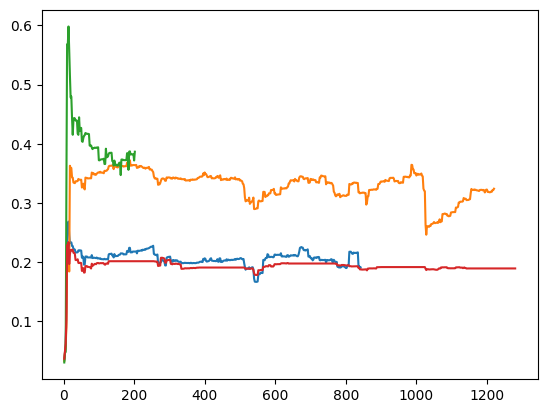

In [104]:
plt.plot(surge_no_rebuilds[
        (surge_no_rebuilds["operation"] == "search") &
        (surge_no_rebuilds["mode"] == "RecallTarget") &
        (surge_no_rebuilds["param"] == .9)
    ]["step"],
    surge_no_rebuilds[
        (surge_no_rebuilds["operation"] == "search") &
        (surge_no_rebuilds["mode"] == "RecallTarget") &
        (surge_no_rebuilds["param"] == .9)
    ]["gini"])

plt.plot(surge_t80[
        (surge_t80["operation"] == "search") &
        (surge_t80["mode"] == "RecallTarget") &
        (surge_t80["param"] == .9)
    ]["step"],
    surge_t80[
        (surge_t80["operation"] == "search") &
        (surge_t80["mode"] == "RecallTarget") &
        (surge_t80["param"] == .9)
    ]["gini"])

plt.plot(surge_t60[
        (surge_t60["operation"] == "search") &
        (surge_t60["mode"] == "RecallTarget") &
        (surge_t60["param"] == .9)
    ]["step"],
    surge_t60[
        (surge_t60["operation"] == "search") &
        (surge_t60["mode"] == "RecallTarget") &
        (surge_t60["param"] == .9)
    ]["gini"])

plt.plot(gpann_results[
        (gpann_results["operation"] == "SEARCH") & 
        (gpann_results["nprobe"] == 7)
    ]["step"],
    gpann_results[
        (gpann_results["operation"] == "SEARCH") & 
        (gpann_results["nprobe"] == 7)
    ]["gini"])